In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [122]:
# UWAGA tu bierzemy zawsze już czyste dane
data = data = pd.read_csv(('../data/merged/clean_data.csv'))

In [123]:
labels = ['1950-1969', '1970-1989', '1990-2009', '2010-obecnie']
data['epoka'] = pd.Categorical(data['epoka'], categories=labels, ordered=True)

In [124]:
print(data.shape)
data.sample(5)

(19225, 50)


,tmdbId,title,budget,revenue,release_date,runtime,original_language,popularity,vote_average,vote_count,...,actor3_name,actor3_popularity,actor3_gender,budget_adjusted,revenue_adjusted,quarter,epoka,total_actors_popularity,total_crew_popularity,main_genre
4874,16523.0,Where the Wild Things Are,100000000.0,100140916,2009-10-16,101,en,3.9701,6.494,1992,...,James Gandolfini,2.8299,2.0,1.500641e+08,1.502756e+08,4,1990-2009,19.8754,2.8193,fantasy
4158,13555.0,The Funhouse,2000000.0,7886999,1981-03-13,96,en,1.3685,5.876,419,...,Largo Woodruff,0.9780,1.0,7.083454e+06,2.793360e+07,1,1970-1989,4.7279,1.2077,horror
4105,13408.0,The Wash,7000000.0,10229331,2001-11-14,97,en,2.1784,5.456,126,...,Bruce Bruce,1.6164,2.0,1.272502e+07,1.859549e+07,4,1990-2009,10.1478,4.2556,action
2956,10559.0,Frequency,31000000.0,68106245,2000-04-28,118,en,4.0011,7.261,1961,...,Elizabeth Mitchell,4.3684,1.0,5.795722e+07,1.273306e+08,2,1990-2009,22.5119,3.8543,sci-fi
11121,153353.0,In the Lap of God,NaN,185544,1991-11-29,88,cn,0.7876,6.000,4,...,Roy Cheung Yiu-Yeung,1.9830,2.0,NaN,4.385800e+05,4,1990-2009,8.2920,1.9627,action


# Statystyki kolumn

In [125]:
# STATYSTYKI OPISOWE  trochę nie mają sensu bo dane aż tak skośne, dużo wartości odstających
num_data = data.loc[:, ['budget_adjusted', 'revenue_adjusted','runtime', 'popularity',
                        'vote_average', 'vote_count']]


stats = num_data.describe().T[['mean', '50%', 'std', 'min', 'max']]
stats.rename(columns={'50%': 'median'}, inplace=True)

stats['skewness'] = num_data.skew()
stats['kurtosis'] = num_data.kurtosis()
stats = round(stats,2)
stats

,mean,median,std,min,max,skewness,kurtosis
budget_adjusted,39209051.33,19587394.72,5.450435e+07,10029.38,6.169198e+08,2.81,10.69
revenue_adjusted,73550170.09,9102404.78,2.022276e+08,10052.91,4.541628e+09,7.18,83.98
runtime,106.88,103.00,2.286000e+01,11.00,5.660000e+02,2.25,21.56
popularity,2.76,1.74,4.900000e+00,0.00,3.193300e+02,22.89,1092.77
vote_average,6.17,6.32,1.310000e+00,0.00,1.000000e+01,-2.01,7.39
vote_count,1058.99,186.00,2.617220e+03,0.00,3.915600e+04,5.39,39.58


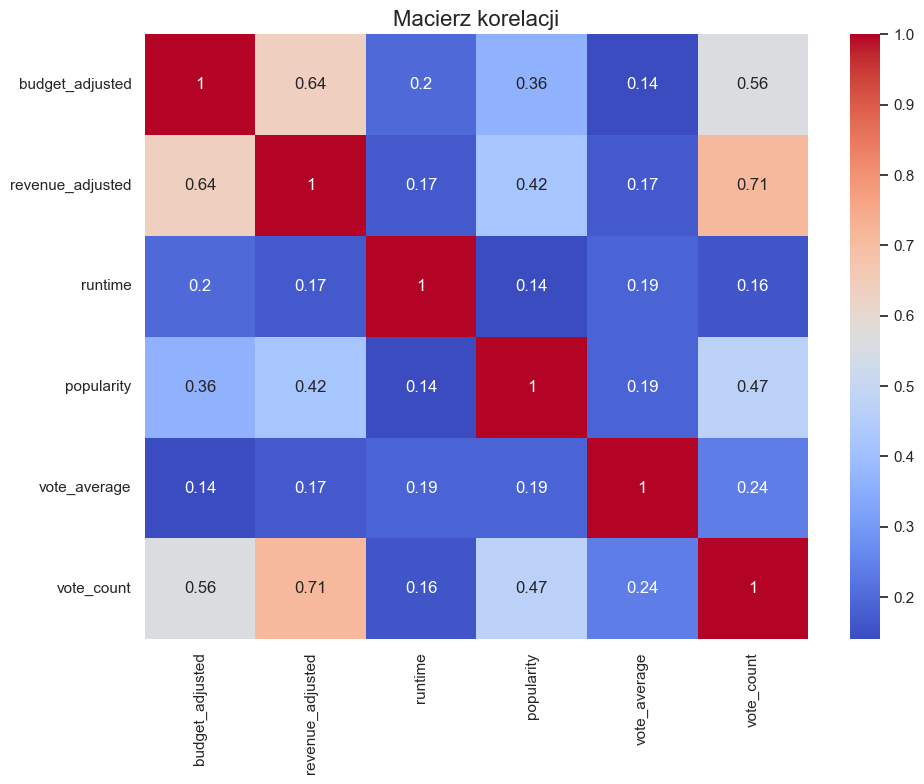

In [126]:
cor_matrix = round(num_data.corr(),2)
plt.figure(figsize=(10, 8))


sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.title('Macierz korelacji', fontsize=16)
plt.tight_layout()
plt.show() 

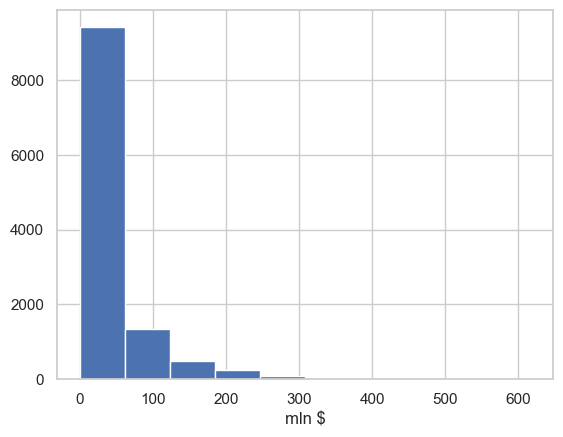

In [127]:
plt.hist(data['budget_adjusted'] / 1e6)
plt.xlabel("mln $")
plt.show()

In [128]:
len(data[data['budget_adjusted'] > 300e6])

60

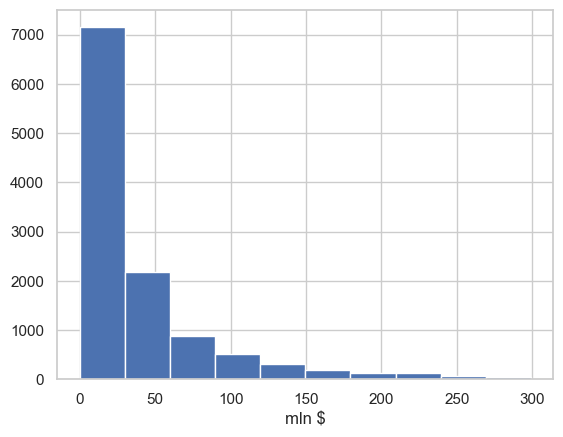

In [129]:
plt.hist(data[data['budget_adjusted'] < 300e6]['budget_adjusted'] / 1e6)
plt.xlabel("mln $")
plt.show()

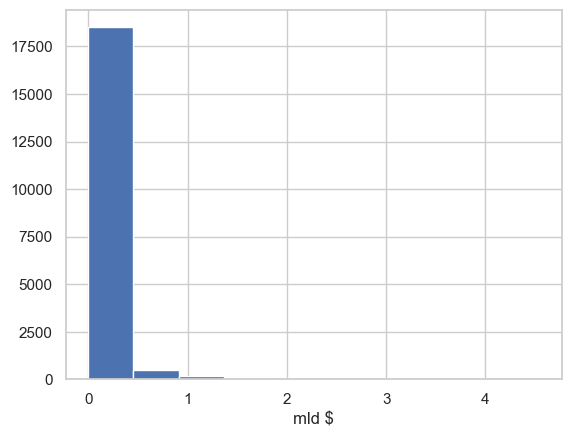

In [130]:
plt.hist(data['revenue_adjusted'] / 1e9)
plt.xlabel("mld $")
plt.show()

In [131]:
len(data[data['revenue_adjusted'] > 2e9])

23

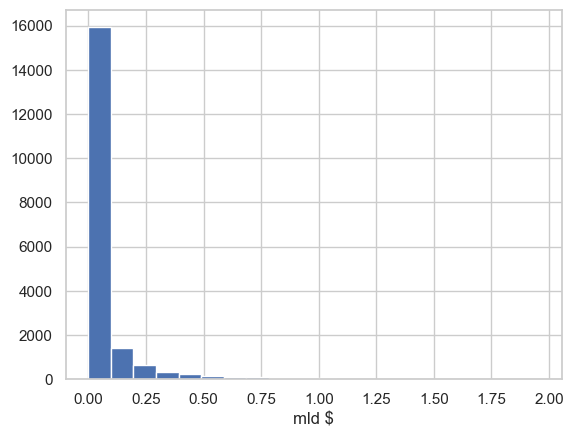

In [132]:
plt.hist(data[data['revenue_adjusted'] < 2e9]['revenue_adjusted'] / 1e9, bins = 20)
plt.xlabel("mld $")
plt.show()

In [133]:
rev = data['revenue_adjusted']
total_movies = len(rev)
less_than_100k = len(rev[rev < 100_000])
less_than_1m = len(rev[rev < 1_000_000])
less_than_10m = len(rev[rev < 10_000_000])
less_than_100m = len(rev[rev < 100_000_000])
less_than_1mld = len(rev[rev < 1000_000_000])

tabela_ryzyka = pd.DataFrame({
    'Revenue_adjusted': ['< 100 tys', '< 1 mln', '< 10 mln', '< 100 mln', '< 1 mld'],
    'Liczba filmów': [less_than_100k, less_than_1m, less_than_10m, less_than_100m, less_than_1mld],
    'Odsetek (%)': [
        round((less_than_100k / total_movies) * 100, 2),
        round((less_than_1m / total_movies) * 100, 2),
        round((less_than_10m / total_movies) * 100, 2),
        round((less_than_100m / total_movies) * 100, 2),
        round((less_than_1mld / total_movies) * 100, 2),
    ]
})
tabela_ryzyka

,Revenue_adjusted,Liczba filmów,Odsetek (%)
0,< 100 tys,1578,8.21
1,< 1 mln,4695,24.42
2,< 10 mln,9834,51.15
3,< 100 mln,15977,83.11
4,< 1 mld,19034,99.01


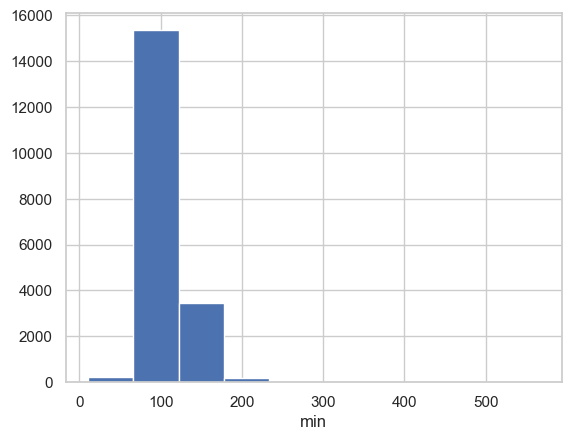

In [134]:
plt.hist(data['runtime'])
plt.xlabel("min")
plt.show()

In [135]:
len(data[data['runtime'] > 300])

10

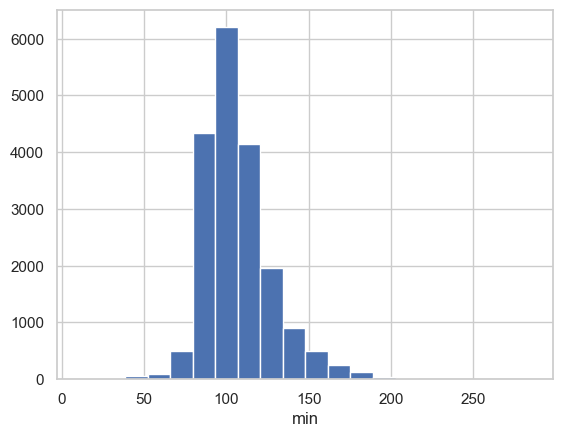

In [136]:
plt.hist(data[data['runtime'] < 300]['runtime'], bins = 20)
plt.xlabel("min")
plt.show()

In [137]:
len(data[data['popularity'] > 30])

58

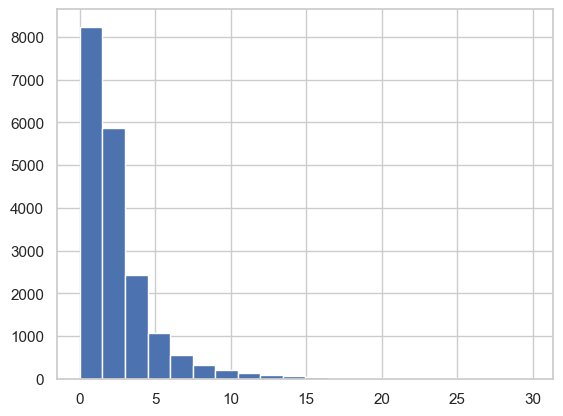

In [138]:
plt.hist(data[data['popularity'] < 30]['popularity'], bins = 20)
plt.show()

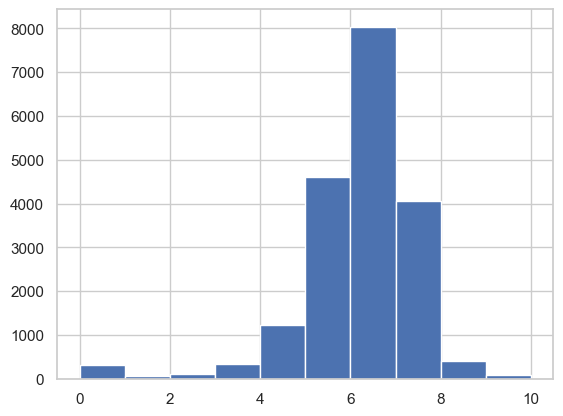

In [139]:
plt.hist(data['vote_average'], bins = 10)
plt.show()

In [140]:
len(data[data['vote_count'] > 20000])

70

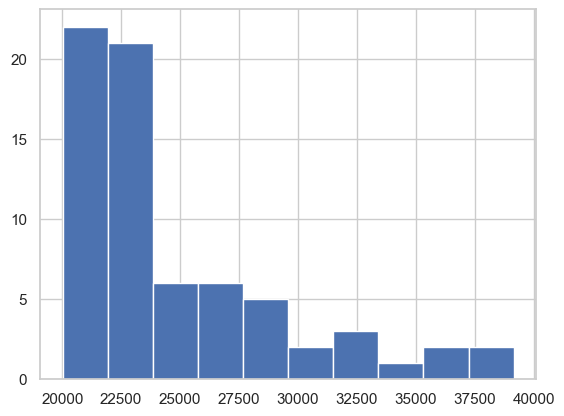

In [141]:
plt.hist(data[data['vote_count'] > 20000]['vote_count'])
plt.show()

# Wizualizacje

In [142]:
data['year'].value_counts().sort_index()

year
1950     22
1951     25
1952     23
1953     31
1954     37
       ... 
2021    424
2022    534
2023    569
2024    638
2025    529
Name: count, Length: 76, dtype: int64

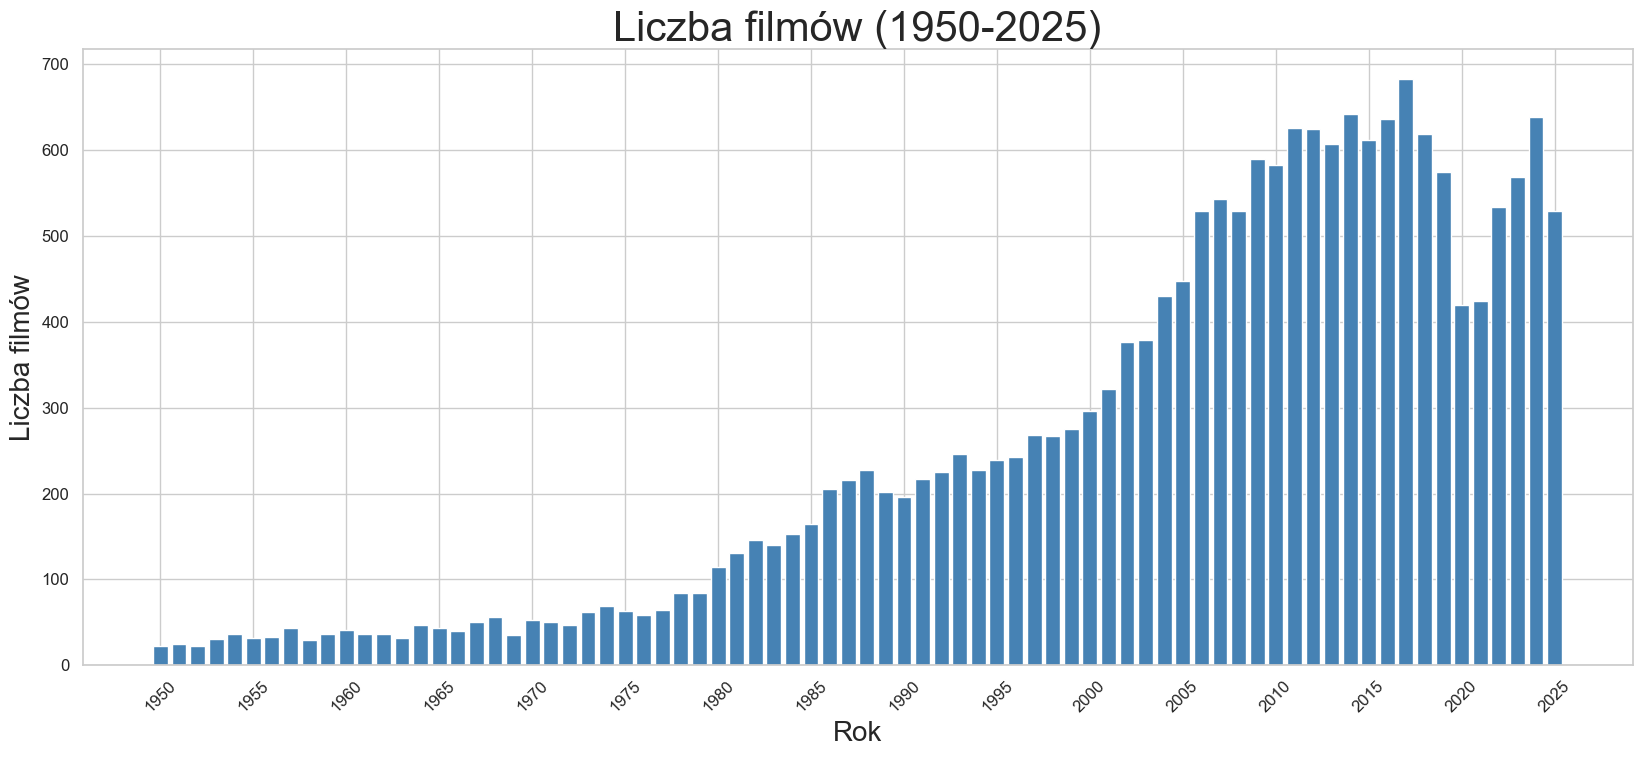

In [143]:
movies_per_year = data['year'].value_counts().sort_index()

plt.figure(figsize=(20, 8))
plt.bar(x = movies_per_year.index,
        height = movies_per_year.values,
        color='steelblue')

plt.title('Liczba filmów (1950-2025)', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Liczba filmów', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

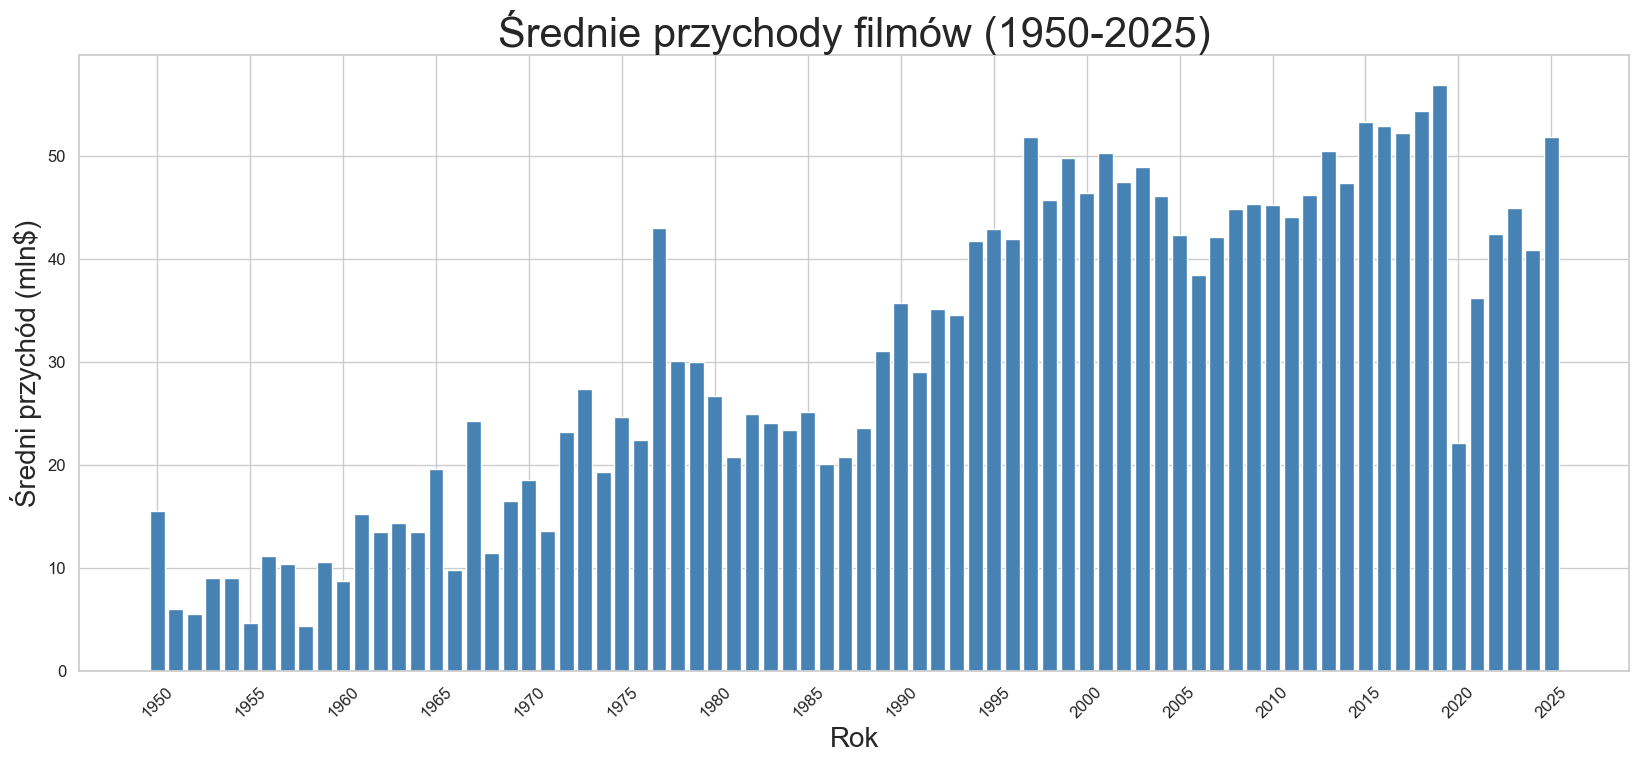

In [144]:
mean_revenue_year = data.groupby('year')['revenue'].mean() / 1e6

plt.figure(figsize=(20, 8))
plt.bar(x = mean_revenue_year.index,
        height = mean_revenue_year.values,
        color='steelblue')

plt.title('Średnie przychody filmów (1950-2025)', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Średni przychód (mln$)', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

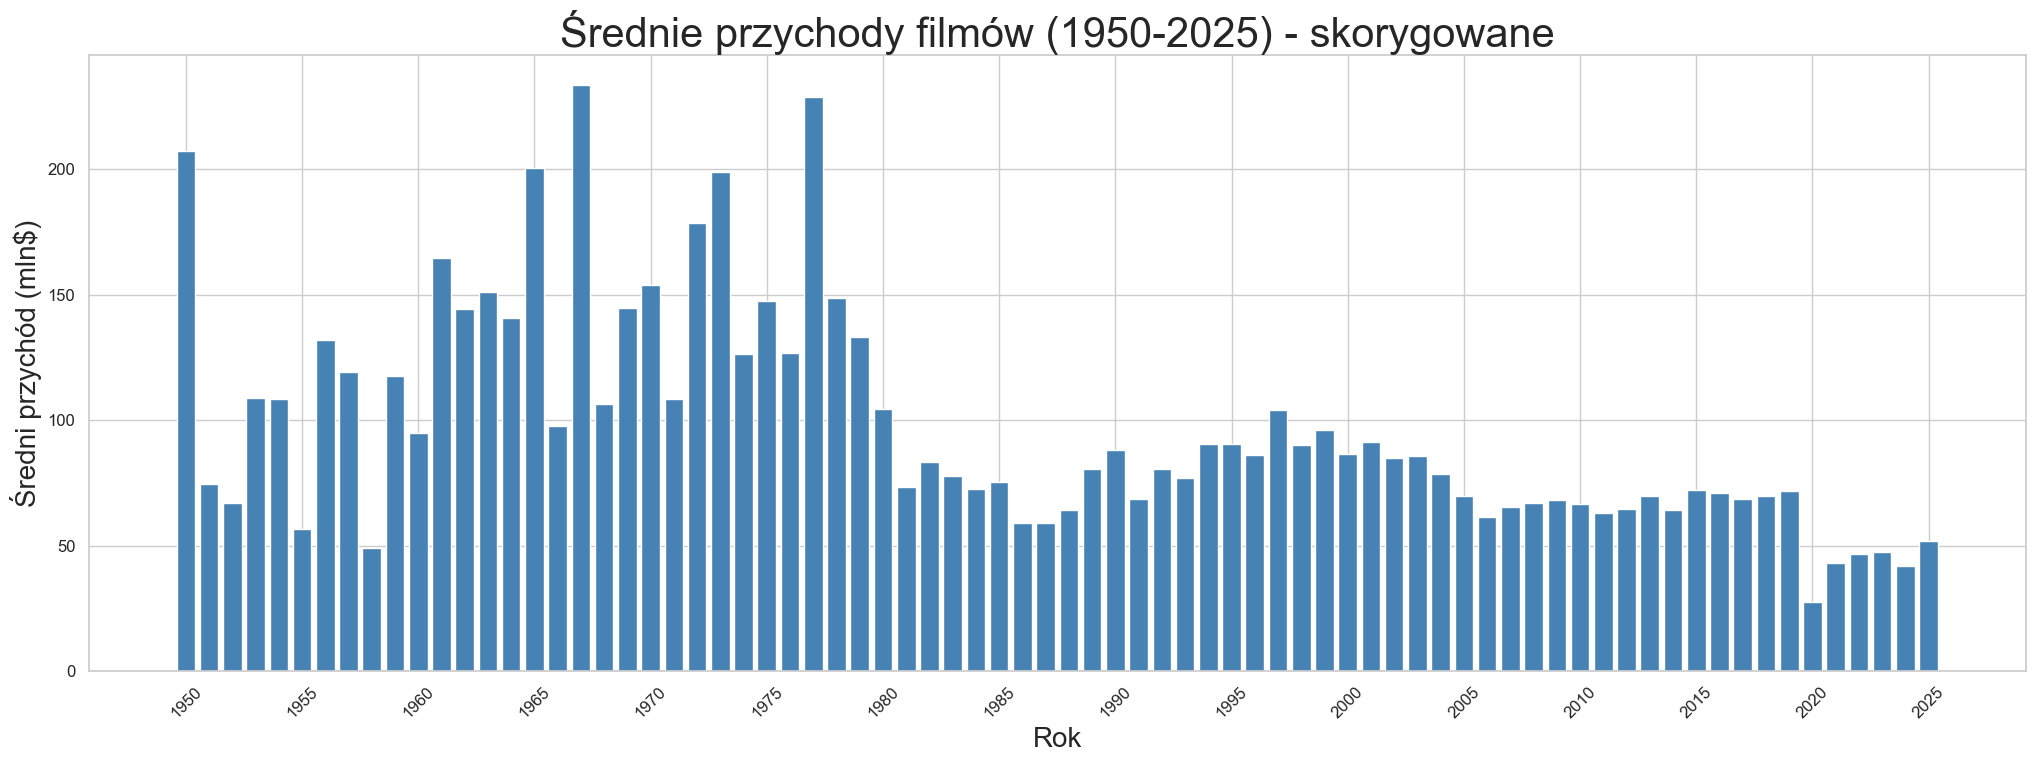

In [145]:
mean_revenue_year = data.groupby('year')['revenue_adjusted'].mean() / 1e6

plt.figure(figsize=(25, 8))
plt.bar(x = mean_revenue_year.index,
        height = mean_revenue_year.values,
        color='steelblue')

plt.title('Średnie przychody filmów (1950-2025) - skorygowane', fontsize=30)
plt.xlabel('Rok', fontsize = 20)
plt.ylabel('Średni przychód (mln$)', fontsize = 20)

plt.xticks(movies_per_year.index[::5], rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

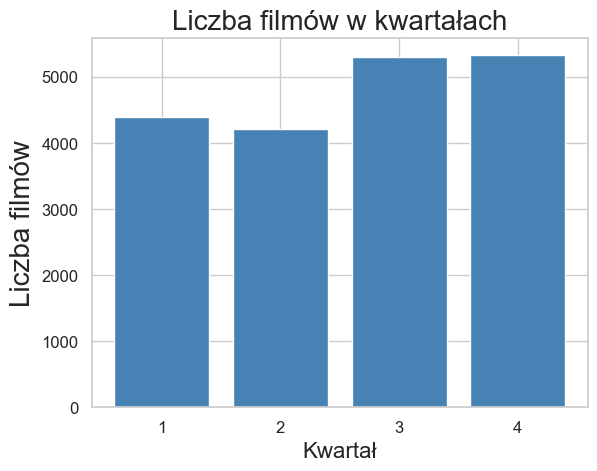

In [146]:
movies_per_quarter = data['quarter'].value_counts().sort_index()

plt.bar(x = movies_per_quarter.index,
        height = movies_per_quarter.values,
        color='steelblue')

plt.title('Liczba filmów w kwartałach', fontsize=20)
plt.xlabel('Kwartał', fontsize = 16)
plt.ylabel('Liczba filmów', fontsize = 20)

plt.xticks(movies_per_quarter.index, fontsize=12)
plt.yticks(fontsize=12)

plt.show()

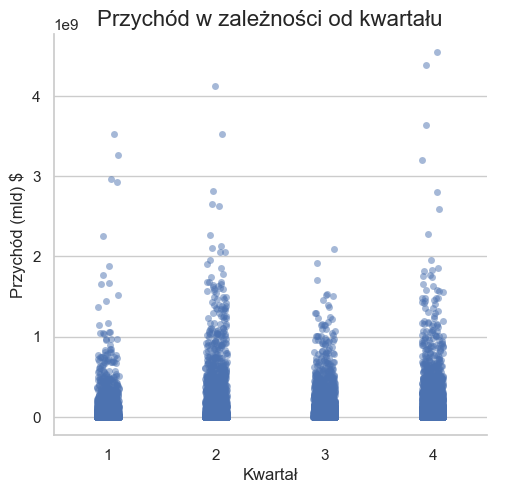

In [147]:
sns.catplot(data=data,  x ="quarter", y ="revenue_adjusted", jitter = True, alpha = 0.5)
plt.title("Przychód w zależności od kwartału", size = 16)
plt.ylabel("Przychód (mld) $")
plt.xlabel("Kwartał")
plt.show()

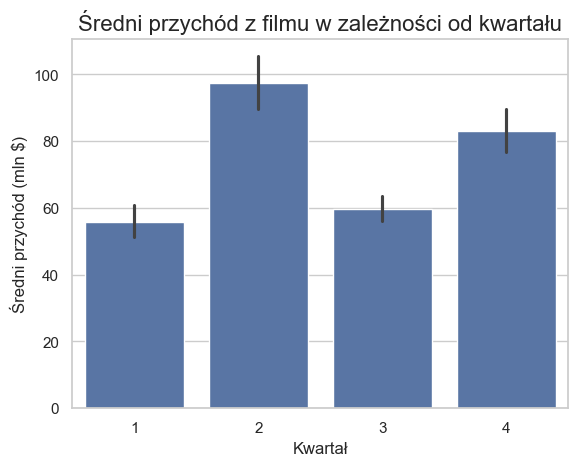

In [148]:
sns.barplot(
    x = data['quarter'], 
    y = (data['revenue_adjusted'] / 1e6), 
    legend=False,  
    errorbar='ci'
)


plt.title('Średni przychód z filmu w zależności od kwartału', fontsize=16)
plt.xlabel('Kwartał', fontsize=12)
plt.ylabel('Średni przychód (mln $)', fontsize=12)

plt.show()

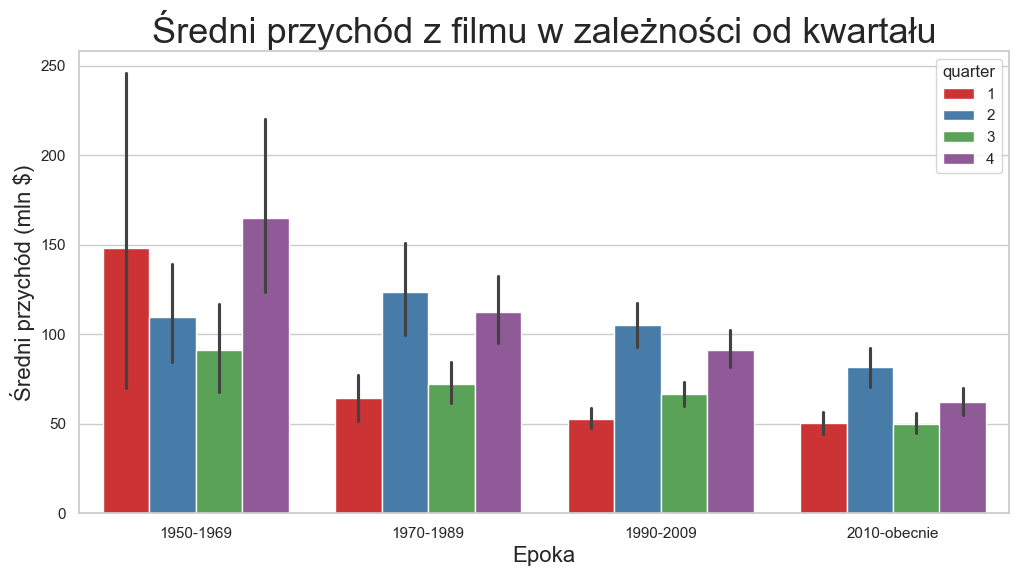

In [149]:
plt.figure(figsize = (12, 6))
sns.barplot(
    x = data['epoka'], 
    y = (data['revenue_adjusted'] / 1e6), 
    hue = data['quarter'],
    legend=True,  
    errorbar='ci',
    palette = 'Set1'
)


plt.title('Średni przychód z filmu w zależności od kwartału', fontsize=26)
plt.xlabel('Epoka', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)

plt.show()

In [150]:
pl_data = data[['revenue_adjusted', 'epoka', 'quarter']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6

tabela = pd.pivot_table(
    pl_data, 
    values='revenue_mln',      
    index='quarter',     
    columns='epoka',         
    aggfunc='mean',         
    margins=True,         
    margins_name='Globalnie' 
)

tabela = round(tabela, 3)
tabela

C:\Users\olkat\AppData\Local\Temp\ipykernel_17892\2990448668.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela = pd.pivot_table(


epoka,1950-1969,1970-1989,1990-2009,2010-obecnie,Globalnie
quarter,,,,,
1,148.121,64.205,52.817,50.279,55.905
2,109.688,123.582,105.272,81.493,97.363
3,91.176,72.260,66.494,49.995,59.748
4,164.961,112.323,91.443,62.436,82.969
Globalnie,129.461,95.120,78.735,59.967,73.550


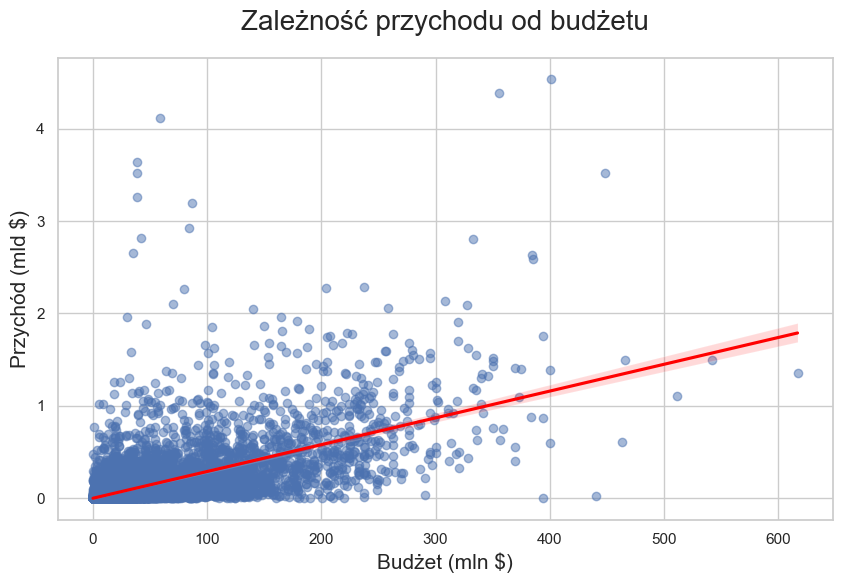

In [151]:
plt.figure(figsize = (10,6))
sns.regplot(x = data['budget_adjusted'] / 1e6, 
            y = data['revenue_adjusted'] / 1e9, 
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'red'})

plt.title('Zależność przychodu od budżetu', fontsize=20, pad=20)
plt.xlabel('Budżet (mln $)', fontsize=15)
plt.ylabel('Przychód (mld $)', fontsize=15)


plt.show()

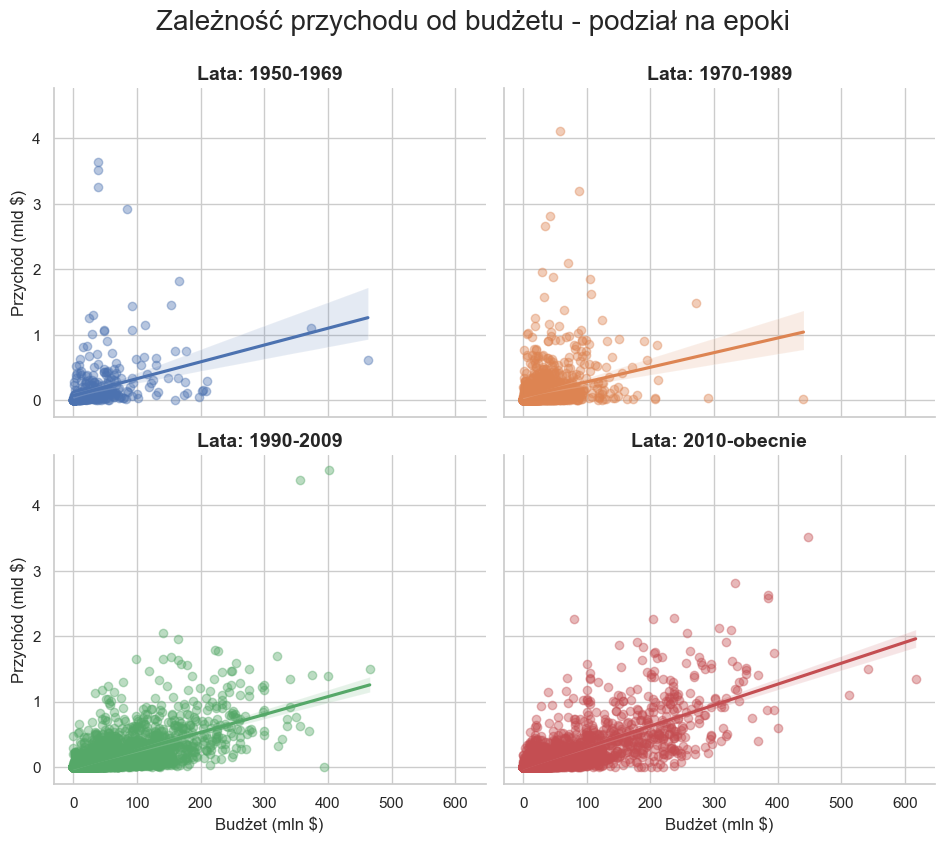

In [152]:
pl_data = data[['year', 'budget_adjusted', 'revenue_adjusted', 'epoka']].copy()

pl_data['budget_mln'] = pl_data['budget_adjusted'] / 1e6
pl_data['revenue_mld'] = pl_data['revenue_adjusted'] / 1e9
pl_data = pl_data.dropna(subset=['budget_mln', 'revenue_mld', 'epoka'])

g = sns.lmplot(
    data=pl_data,
    x='budget_mln',
    y='revenue_mld',
    col='epoka',
    hue = 'epoka' ,      
    col_wrap=2,     
    height=4,      
    aspect=1.2,     
    scatter_kws={'alpha': 0.4},   
)


g.set_axis_labels('Budżet (mln $)', 'Przychód (mld $)')
g.set_titles(col_template='Lata: {col_name}', size=14, weight='bold')

g.figure.suptitle('Zależność przychodu od budżetu - podział na epoki', fontsize=20, y=1.05)

plt.show()

In [153]:
data[['title', 'year', 'revenue_adjusted']].sort_values('revenue_adjusted', ascending=False).head(20)

,title,year,revenue_adjusted
361,Titanic,1997,4.541628e+09
5422,Avatar,2009,4.387433e+09
2,Star Wars,1977,4.119372e+09
2166,The Jungle Book,1967,3.643547e+09
12763,Avengers: Endgame,2019,3.525269e+09
3343,Cinderella,1950,3.521335e+09
3829,One Hundred and One Dalmatians,1961,3.262499e+09
2339,The Exorcist,1973,3.199897e+09
8912,The Dollars Are Coming!,1957,2.960367e+09
4583,The Sound of Music,1965,2.925228e+09


In [154]:
data[['title', 'year', 'budget_adjusted']].sort_values('budget_adjusted', ascending=False).head(20)

,title,year,budget_adjusted
11422,Star Wars: The Rise of Skywalker,2019,6.169198e+08
896,Pirates of the Caribbean: On Stranger Tides,2011,5.424422e+08
15279,Jurassic World Dominion,2022,5.115358e+08
178,Pirates of the Caribbean: At World's End,2007,4.658145e+08
1812,Cleopatra,1963,4.629246e+08
12763,Avengers: Endgame,2019,4.483026e+08
3465,Manhunter,1986,4.406154e+08
361,Titanic,1997,4.011751e+08
330,Spider-Man 3,2007,4.006004e+08
15901,Mission: Impossible - The Final Reckoning,2025,4.000000e+08


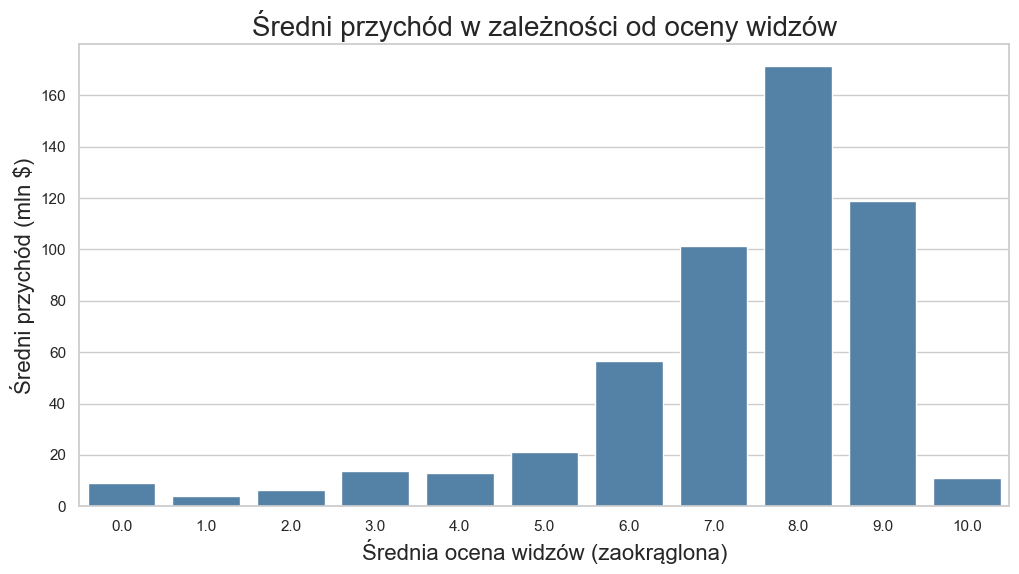

In [155]:
pl_data = data[['revenue_adjusted', 'vote_average', 'epoka']].copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6
pl_data['vote_rounded'] = pl_data['vote_average'].round()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=pl_data,
    x='vote_rounded',
    y='revenue_mln',
    color='steelblue',
    errorbar=None
)

plt.title('Średni przychód w zależności od oceny widzów', fontsize=20)
plt.xlabel('Średnia ocena widzów (zaokrąglona)', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)

plt.show()

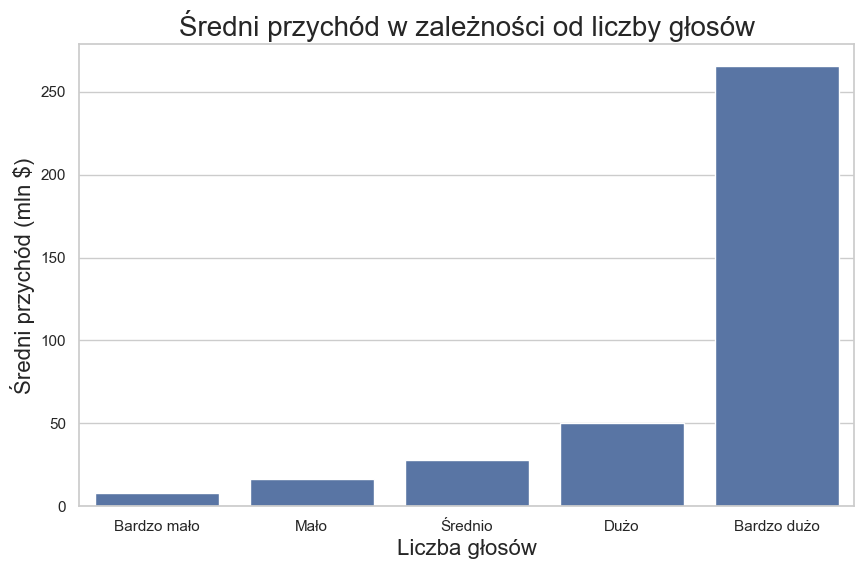

In [156]:
pl_data = data[['revenue_adjusted', 'vote_count']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e6

labels = ['Bardzo mało', 'Mało', 'Średnio', 'Dużo', 'Bardzo dużo']
pl_data['vote_category'] = pd.qcut(pl_data['vote_count'], q=5, labels=labels)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=pl_data,
    x='vote_category',
    y='revenue_mln',
    errorbar=None    
)


plt.title('Średni przychód w zależności od liczby głosów', fontsize=20)
plt.xlabel('Liczba głosów', fontsize=16)
plt.ylabel('Średni przychód (mln $)', fontsize=16)


plt.show()

Próg wejścia do grupy 'Bardzo dużo': 2711 głosów



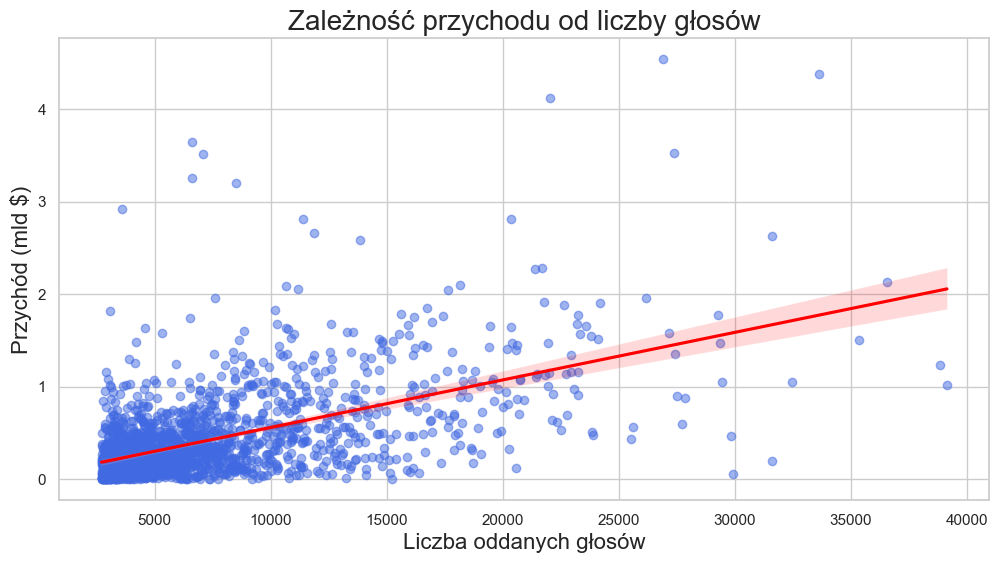

In [157]:
pl_data = data[['revenue_adjusted', 'vote_count']].dropna().copy()
pl_data['revenue_mln'] = pl_data['revenue_adjusted'] / 1e9

prog_odciecia = pl_data['vote_count'].quantile(0.9)
print(f"Próg wejścia do grupy 'Bardzo dużo': {round(prog_odciecia)} głosów\n")

pl_data = pl_data[pl_data['vote_count'] >= prog_odciecia]

plt.figure(figsize=(12, 6))

sns.regplot(
    data=pl_data,
    x='vote_count',
    y='revenue_mln', 
    color='royalblue',
    scatter_kws={'alpha': 0.5}, 
    line_kws={'color': 'red'}
)

plt.title('Zależność przychodu od liczby głosów', fontsize=20)
plt.xlabel('Liczba oddanych głosów', fontsize=16)
plt.ylabel('Przychód (mld $)', fontsize=16)

plt.show()

In [158]:
data['main_genre'].value_counts()

main_genre
comedy         4733
action         2502
romance        1549
drama          1496
horror         1387
thriller       1146
crime           940
animation       915
adventure       840
documentary     633
family          568
history         525
fantasy         426
sci-fi          423
musical         357
mystery         317
war             277
western         150
Name: count, dtype: int64

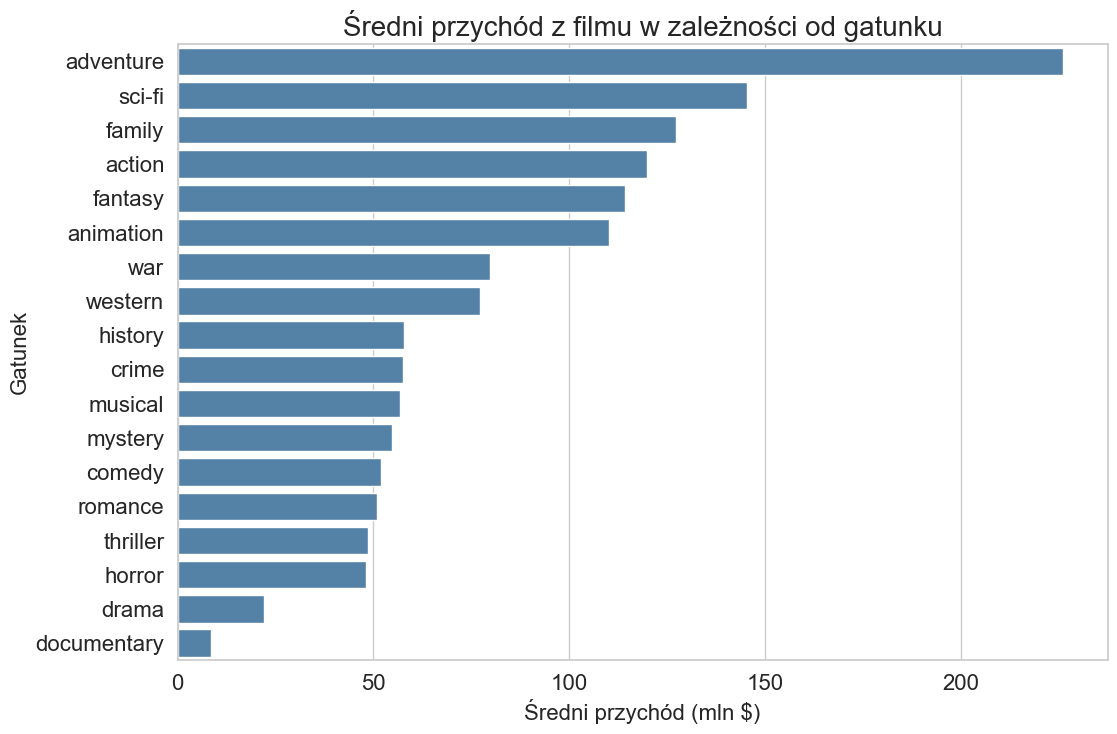

In [159]:
pl_data_rev = data[['revenue_adjusted', 'main_genre']].dropna().copy()
pl_data_rev['revenue_mln'] = pl_data_rev['revenue_adjusted'] / 1e6

plt.figure(figsize=(12, 8))

sns.barplot(
    data=pl_data_rev, 
    x='revenue_mln', 
    y='main_genre', 
    color='steelblue', 
    errorbar=None, 
    order=pl_data_rev.groupby('main_genre')['revenue_mln'].mean().sort_values(ascending=False).index 
)

plt.title('Średni przychód z filmu w zależności od gatunku', fontsize=20)
plt.xlabel('Średni przychód (mln $)', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()

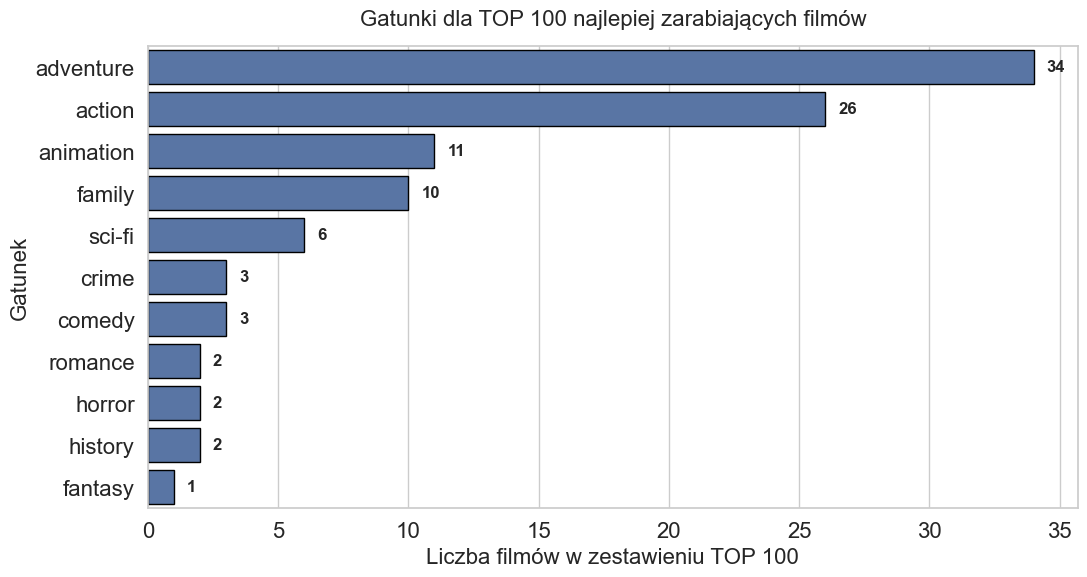

In [160]:
top_100 = data.nlargest(100, 'revenue_adjusted')
ilosc_w_top100 = top_100['main_genre'].value_counts()

plt.figure(figsize=(12, 6))

wykres = sns.barplot(
    x=ilosc_w_top100.values, 
    y=ilosc_w_top100.index, 
    edgecolor='black'
)


plt.title('Gatunki dla TOP 100 najlepiej zarabiających filmów', fontsize=16, pad=15)
plt.xlabel('Liczba filmów w zestawieniu TOP 100', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

for index, value in enumerate(ilosc_w_top100.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=12, fontweight='bold')

plt.show()

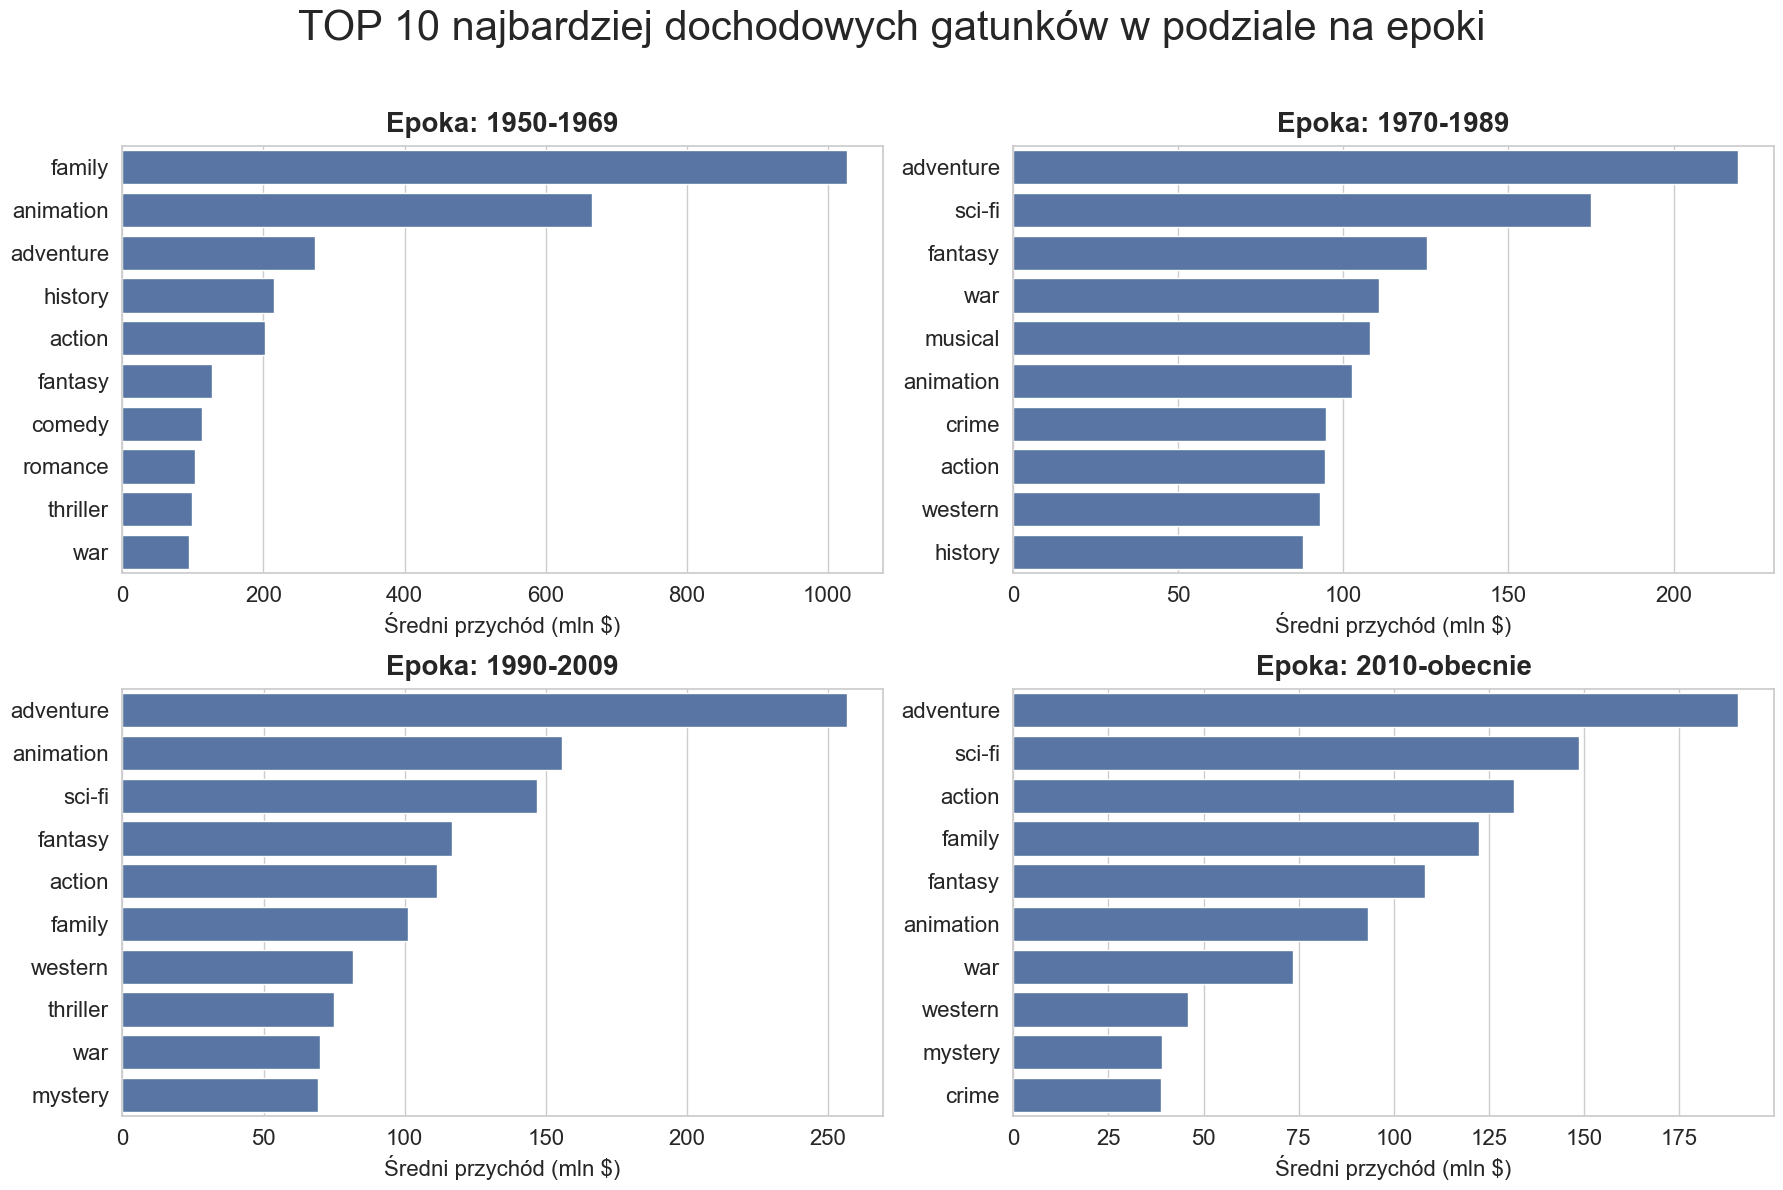

In [161]:
kolejnosc_epok = ['1950-1969', '1970-1989', '1990-2009', '2010-obecnie']


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten() 

for i, epoka in enumerate(kolejnosc_epok):

    dane_epoki = data[data['epoka'] == epoka]
    
    ranking = (dane_epoki.groupby('main_genre')['revenue_adjusted']
               .mean() 
               .divide(1e6)
               .sort_values(ascending=False)
               .head(10))
    
    sns.barplot(x=ranking.values, y=ranking.index, ax=axes[i])
    

    axes[i].set_title(f'Epoka: {epoka}', fontsize=20, fontweight='bold', pad=10)
    axes[i].set_xlabel('Średni przychód (mln $)', fontsize=16)
    axes[i].set_ylabel('', fontsize=16)
    axes[i].tick_params(labelsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('TOP 10 najbardziej dochodowych gatunków w podziale na epoki', fontsize=30, y=1.02)

plt.show()